# Advanced Model Analysis - Random Forest and XGBoost

This notebook extends the modelling analysis by implementing more flexible machine learning algorithms, **Random Forest** and **XGBoost**, to predict customer response to the monthly food basket subscription campaign. While logistic regression provides a useful baseline and interpretable benchmark, tree-based ensemble methods can capture non-linear relationships, complex feature interactions, and heterogeneous customer behaviour that linear models may miss.

The modelling strategy follows a structured evaluation framework:

1.	**A Random Forest Model** to capture non-linear patterns and interactions between customer characteristics while maintaining robustness through ensemble averaging.
2.	**An XGBoost Model**, a gradient boosting approach designed to iteratively correct prediction errors and produce highly accurate probability estimates.

Comparing these models allows us to evaluate improvements over the logistic regression baseline and identify the most effective modelling approach for targeting customers with the highest probability of responding to the campaign.


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier
from typing import cast


# Sklearn — preprocessing & splitting
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    RandomizedSearchCV, StratifiedKFold,
    learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import randint, uniform

# Sklearn — models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Sklearn — evaluation
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

# OOF threshold tuning helper
def find_best_threshold_oof(model, X_tr, y_tr, cv=5):
    """
    Select the F1-optimal classification threshold using out-of-fold (OOF)
    probability estimates on the training set ONLY.

    Each observation is scored by a fold of the model that was trained
    without it, so no test-set information leaks into the threshold decision.
    The test set is then touched exactly once — for final evaluation.

    Optimisation criterion: F1-score, which balances precision and recall.
    In a marketing context this rewards models that catch real responders
    (recall) while not wasting budget on non-responders (precision).
    """
    cv_strat = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    oof_probs = cross_val_predict(
        model, X_tr, y_tr, cv=cv_strat, method="predict_proba"
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_tr, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_idx       = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1        = f1_scores[best_idx]

    print(f"Optimal threshold (F1-maximising): {best_threshold:.4f}")
    print(f"Best OOF F1:                        {best_f1:.4f}")
    return best_threshold, oof_probs, precisions, recalls, thresholds, f1_scores



In [2]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns


Dataset shape: 2236 rows × 30 columns

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

Using the previously defined feature sets, three input matrices are created: `X_full`, `X_behav`, and `X_demo`, corresponding to the full, behavioural, and demographic feature configurations. Categorical variables are converted into dummy variables where necessary. The target variable y corresponds to the campaign response indicator.

In [3]:
# Create copy of the dataframe for modeling
df_model = df.copy()

# Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]
df_model = df_model.drop(columns=cols_to_drop)

# Target
target = 'Response'

# Full Model: all available features
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

print(f"Full model: {len(numerical_features_full)} numerical + {len(categorical_features_full)} categorical features")


Full model: 11 numerical + 2 categorical features


In [4]:
X_full  = pd.concat([df_model[numerical_features_full],
                     pd.get_dummies(df_model[categorical_features_full],  drop_first=True)], axis=1)

y = df_model[target].copy()

print(f"\nX_full  shape : {X_full.shape}")
print(f"y       shape : {y.shape}  | Positive rate: {y.mean():.1%}")



X_full  shape : (2236, 20)
y       shape : (2236,)  | Positive rate: 14.9%


## 2. Train/Test Split

Loading the train/test split data created during the EDA.

In [5]:
# Load the shared split indices produced in EDA.ipynb (Section 9)
idx_train = np.load('../data/idx_train.npy')
idx_test  = np.load('../data/idx_test.npy')

# Full model splits
X_train, X_test = X_full.iloc[idx_train], X_full.iloc[idx_test]
y_train = y.iloc[idx_train]
y_test  = y.iloc[idx_test]

print(f'Train size : {len(y_train):,} rows | Test size : {len(y_test):,} rows')
print(f'Train positive rate: {y_train.mean():.1%}')
print(f'Test  positive rate: {y_test.mean():.1%}')

Train size : 1,788 rows | Test size : 448 rows
Train positive rate: 14.9%
Test  positive rate: 15.0%


## 3. Full Model - Random Forest

The first advanced model is a Random Forest classifier trained on the full feature set. Random Forest is an ensemble method that combines multiple decision trees to capture non-linear relationships and interactions between variables.

Using the full set of features provides a comprehensive benchmark and allows us to evaluate how well the model performs when all available information about the customer is used.

### 3.1 Baseline Model before tuning

Before performing hyperparameter tuning, a baseline Random Forest model is trained using the default configuration. This provides a reference level of performance for comparison with the tuned model in section 3.3.

To address the class imbalance in the dataset, the parameter `class_weight='balanced'` is applied so that the minority class (customers who responded to the campaign) receives greater weight during training.

In [6]:
rf_default = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_default.fit(X_train, y_train)

y_pred_default  = rf_default.predict(X_test)
y_prob_default  = rf_default.predict_proba(X_test)[:, 1]

print(f"Default RF — ROC-AUC   : {roc_auc_score(y_test, y_prob_default):.4f}")
print(f"Default RF — Recall    : {recall_score(y_test, y_pred_default):.4f}")
print(f"Default RF — Precision : {precision_score(y_test, y_pred_default):.4f}")
print(f"Default RF — F1        : {f1_score(y_test, y_pred_default):.4f}")

Default RF — ROC-AUC   : 0.8636
Default RF — Recall    : 0.2836
Default RF — Precision : 0.6552
Default RF — F1        : 0.3958


### 3.2 Out-of-Bag (OOB) Score Evaluation

Random Forest models use bootstrap sampling when building individual trees. Observations that are not included in a given bootstrap sample are called **out-of-bag (OOB) observations**.

These observations can be used as an internal validation set to estimate model performance during training. The OOB score therefore provides a quick indication of how well the model generalises without requiring an additional validation split.

In [7]:
rf_oob = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

print(f"OOB Score (accuracy proxy): {rf_oob.oob_score_:.4f}")
print("Note: OOB uses ~1/3 of data excluded from each bootstrap sample.")
print("It serves as a built-in cross-validation estimate.")

OOB Score (accuracy proxy): 0.8814
Note: OOB uses ~1/3 of data excluded from each bootstrap sample.
It serves as a built-in cross-validation estimate.


### 3.3 Hyperparameter tuning via RandomizedSearchCV and GridSearchCV

To improve model performance, we tune key Random Forest hyperparameters using **RandomizedSearchCV**. This method samples different combinations of parameters from predefined distributions and evaluates them using stratified **5-fold cross-validation**.

We use **ROC-AUC** as the optimisation metric, since the goal is to distinguish between customers who respond to the campaign and those who do not. It evaluates the model's ability to rank customers by their likelihood to respond, without committing to a threshold yet and gives a clean picture of overall model quality.

In [8]:
param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [None, 5, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator  = RandomForestClassifier(
                     random_state=42,
                     class_weight='balanced',
                     n_jobs=1
                 ),
    param_distributions = param_dist,
    n_iter     = 50,
    cv         = cv_strategy,
    scoring    = 'roc_auc',
    random_state = 42,
    n_jobs     = 1,
    verbose    = 1
)

random_search.fit(X_train, y_train)

print(f"Best parameters : {random_search.best_params_}")
print(f"Best CV AUC     : {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 413}
Best CV AUC     : 0.8866


Based on the results from the RandomizedSearch we will now peform a more specific GridSearch around the best model parameters found so far.

In [9]:
# Tighten around best_params from RandomizedSearchCV
rf_grid = {
    'n_estimators':      [150, 200, 300],
    'max_depth':         [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

rf_grid_search_r1 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=rf_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1, verbose=1
)

rf_grid_search_r1.fit(X_train, y_train)

print(f"Best parameters : {rf_grid_search_r1.best_params_}")
print(f"Best CV AUC     : {rf_grid_search_r1.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV AUC     : 0.8882


In [10]:
# Tighten around best_params from RandomizedSearchCV
rf_grid = {
    'n_estimators':      [175, 200, 225, 250],
    'max_depth':         [8, 9, 10, 11, 12],
    'min_samples_split': [8, 10, 12],
    'min_samples_leaf':  [1, 2],
}

rf_grid_search_r2 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=rf_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1, verbose=1
)

rf_grid_search_r2.fit(X_train, y_train)

print(f"Best parameters : {rf_grid_search_r2.best_params_}")
print(f"Best CV AUC     : {rf_grid_search_r2.best_score_:.4f}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters : {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 175}
Best CV AUC     : 0.8888


### 3.4 Tuning Progression & Best Parameter Selection

Three rounds of search progressively narrowed the parameter space. The table and chart below compare all rounds; the best parameters (highest CV AUC) are then used to rebuild `best_rf` for all subsequent evaluation.

=== Hyperparameter Tuning Progression — Random Forest ===
                                      n_estimators  max_depth  min_samples_split  min_samples_leaf  CV AUC
Round                                                                                                     
Round 1\nRandomizedSearch (50 iter)            413         20                 13                 1  0.8866
Round 1\nGridSearch (120 candidates)           200         10                 10                 1  0.8882
Round 2\nGridSearch (120 candidates)           175         12                  8                 2  0.8888


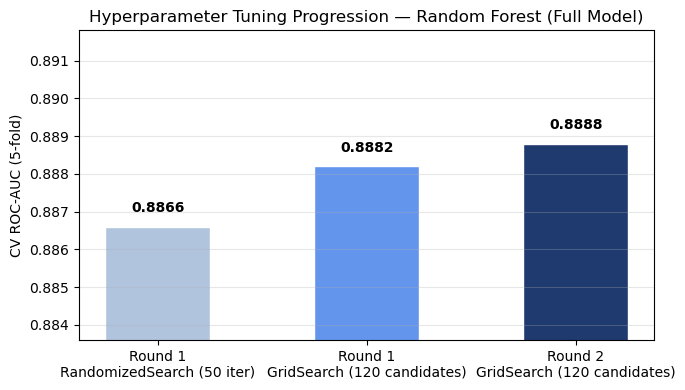


Final best parameters (Round 3): {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 175}
Best CV AUC : 0.8888
best_rf rebuilt with optimised parameters.


In [11]:
# Tuning Progression Summary
tuning_summary = [
    {
        'Round': 'Round 1\nRandomizedSearch (50 iter)',
        'n_estimators': random_search.best_params_['n_estimators'],
        'max_depth': random_search.best_params_['max_depth'],
        'min_samples_split': random_search.best_params_['min_samples_split'],
        'min_samples_leaf': random_search.best_params_['min_samples_leaf'],
        'CV AUC': round(random_search.best_score_, 4),
    },
    {
        'Round': 'Round 1\nGridSearch (120 candidates)',
        'n_estimators': rf_grid_search_r1.best_params_['n_estimators'],
        'max_depth': rf_grid_search_r1.best_params_['max_depth'],
        'min_samples_split': rf_grid_search_r1.best_params_['min_samples_split'],
        'min_samples_leaf': rf_grid_search_r1.best_params_['min_samples_leaf'],
        'CV AUC': round(rf_grid_search_r1.best_score_, 4),
    },
    {
        'Round': 'Round 2\nGridSearch (120 candidates)',
        'n_estimators': rf_grid_search_r2.best_params_['n_estimators'],
        'max_depth': rf_grid_search_r2.best_params_['max_depth'],
        'min_samples_split': rf_grid_search_r2.best_params_['min_samples_split'],
        'min_samples_leaf': rf_grid_search_r2.best_params_['min_samples_leaf'],
        'CV AUC': round(rf_grid_search_r2.best_score_, 4),
    },
]

tuning_df = pd.DataFrame(tuning_summary).set_index('Round')
print("=== Hyperparameter Tuning Progression — Random Forest ===")
print(tuning_df.to_string())

# Bar chart: CV AUC progression
aucs   = [r['CV AUC'] for r in tuning_summary]
labels = [r['Round']  for r in tuning_summary]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, aucs, color=['#b0c4de', '#6495ed', '#1e3a6e'], edgecolor='white', width=0.5)
ax.set_ylim(min(aucs) - 0.003, max(aucs) + 0.003)
ax.set_ylabel("CV ROC-AUC (5-fold)")
ax.set_title("Hyperparameter Tuning Progression — Random Forest (Full Model)")
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
            f"{auc:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Rebuild best_rf with best parameter
best_params_final = rf_grid_search_r2.best_params_
print(f"\nFinal best parameters (Round 3): {best_params_final}")
print(f"Best CV AUC : {rf_grid_search_r2.best_score_:.4f}")

best_rf = RandomForestClassifier(
    **best_params_final,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
print("best_rf rebuilt with optimised parameters.")

### 3.4 Evaluate best model on test set

Our business problem is to rank customers by likelihood to respond for which we use the AUC as main metric but also report **precision, recall, f1** to show trade-offs.

ROC-AUC    : 0.8792   
Precision  : 0.6471
Recall     : 0.4925   
F1-Score   : 0.5593
Accuracy   : 0.8839  

Full classification report:
              precision    recall  f1-score   support

 No Response       0.91      0.95      0.93       381
    Response       0.65      0.49      0.56        67

    accuracy                           0.88       448
   macro avg       0.78      0.72      0.75       448
weighted avg       0.87      0.88      0.88       448



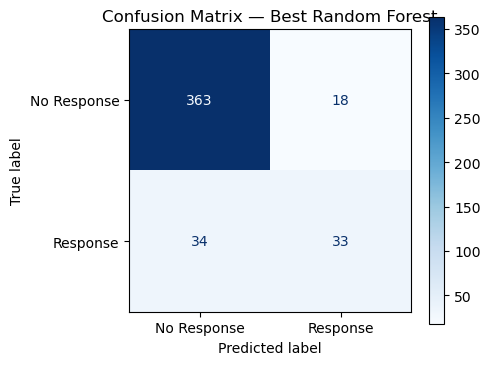

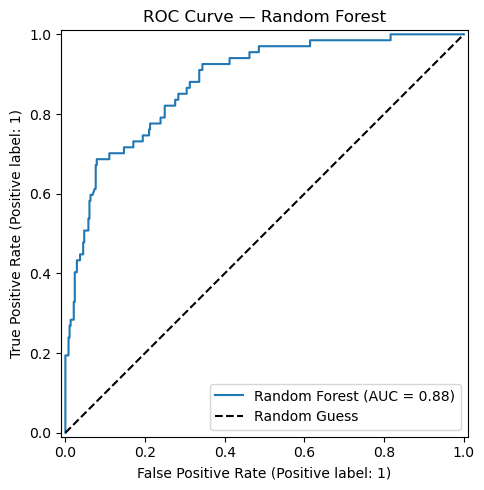

In [12]:
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

auc_rf   = roc_auc_score(y_test, y_prob_best)
prec_rf  = precision_score(y_test, y_pred_best)
rec_rf   = recall_score(y_test, y_pred_best)
f1_rf    = f1_score(y_test, y_pred_best)
acc_rf   = accuracy_score(y_test, y_pred_best)

print(f"ROC-AUC    : {auc_rf:.4f}   ")
print(f"Precision  : {prec_rf:.4f}")
print(f"Recall     : {rec_rf:.4f}   ")
print(f"F1-Score   : {f1_rf:.4f}")
print(f"Accuracy   : {acc_rf:.4f}  ")
print("\nFull classification report:")
print(classification_report(y_test, y_pred_best, target_names=['No Response', 'Response']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test, y_test,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix — Best Random Forest")
plt.tight_layout()
plt.show()

# ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax.set_title("ROC Curve — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()


The tuned Random Forest achieves a **ROC-AUC** of approximately **0.88**, indicating strong ability to distinguish between customers who respond to the campaign and those who do not.

Looking at the classification metrics, the model achieves **precision** of **0.65** and **recall** of **0.49** for the responding class. This suggests that while the model identifies a meaningful portion of responders, some potential responders are still missed, which is expected given the class imbalance in the dataset.

The confusion matrix indicates that the model performs well in identifying non-responding customers, which is expected given the class imbalance. However, the relatively low recall suggests that a significant share of actual responders are not detected. While the model achieves a reasonable precision, implying controlled false positives, it prioritizes precision over recall, limiting its effectiveness in fully capturing the target group.

The ROC curve further confirms strong discrimination performance, with the model clearly outperforming the random baseline.

### 3.5 Threshold Tuning

In marketing applications, it is often **more costly to miss a potential buyer (false negative)** than to contact a customer who ultimately does not purchase (false positive).

In this marketing campaign context:
- A **false negative** (missed responder) is a lost sale — the company never contacts a customer who would have converted.
- A **false positive** (contacted non-responder) wastes campaign budget, but the marginal cost of one email is low.

To explore this trade-off, we evaluate model performance under several probability thresholds. Lower thresholds increase recall by identifying a larger share of potential responders, while higher thresholds improve precision by reducing false positives.

Optimal threshold (F1-maximising): 0.4119
Best OOF F1:                        0.5903


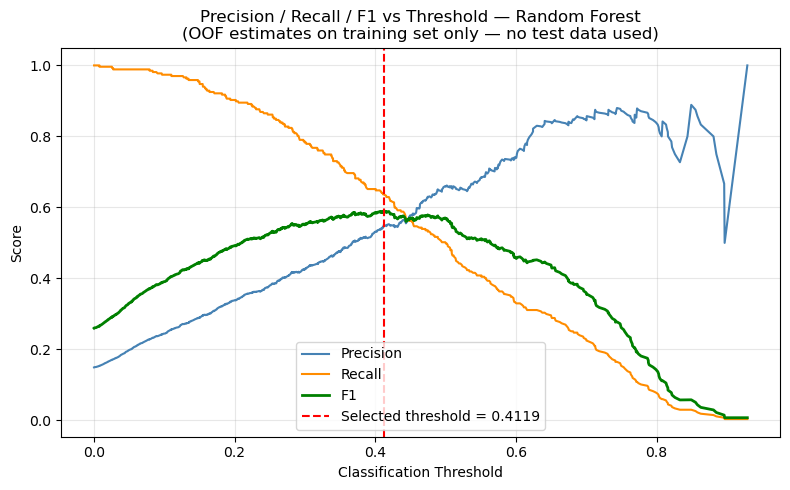

In [13]:
# OOF threshold selection
threshold_rf, oof_probs_rf, prec_rf_curve, rec_rf_curve, thresh_rf_curve, f1_rf_curve = \
    find_best_threshold_oof(best_rf, X_train, y_train)

# Visualise the full precision / recall / F1 trade-off across all thresholds
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresh_rf_curve, prec_rf_curve[:-1], label='Precision', color='steelblue')
ax.plot(thresh_rf_curve, rec_rf_curve[:-1],  label='Recall',    color='darkorange')
ax.plot(thresh_rf_curve, f1_rf_curve[:-1],   label='F1',        color='green', linewidth=2)
ax.axvline(threshold_rf, color='red', linestyle='--',
           label=f'Selected threshold = {threshold_rf:.4f}')
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold — Random Forest\n(OOF estimates on training set only — no test data used)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Classification report at OOF-selected threshold = 0.4119:
              precision    recall  f1-score   support

 No Response       0.94      0.91      0.93       381
    Response       0.57      0.69      0.63        67

    accuracy                           0.88       448
   macro avg       0.76      0.80      0.78       448
weighted avg       0.89      0.88      0.88       448



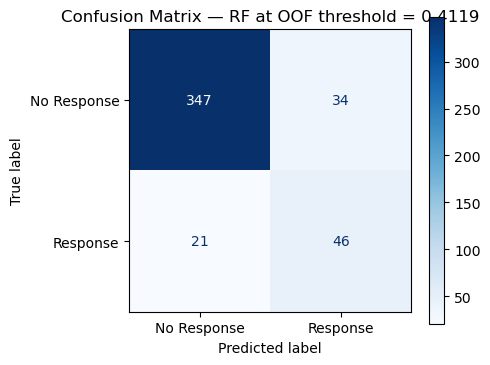

RF scores and threshold saved.


In [14]:
# Apply the OOF-selected threshold to the test set
y_pred_rf_tuned = (y_prob_best >= threshold_rf).astype(int)

print(f"Classification report at OOF-selected threshold = {threshold_rf:.4f}:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=['No Response', 'Response']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_tuned,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — RF at OOF threshold = {threshold_rf:.4f}")
plt.tight_layout()
plt.show()

# Save RF scores and threshold for cross-notebook comparison
np.save('../data/rf_y_prob.npy',     y_prob_best)
np.save('../data/rf_y_pred.npy',     y_pred_rf_tuned)
np.save('../data/rf_threshold.npy',  np.array([threshold_rf]))
print(f"RF scores and threshold saved.")


The threshold is now derived from a principled optimisation over the full precision-recall trade-off curve, using only training data.

The threshold curve shows the characteristic trade-off: as the threshold decreases, recall rises (more true responders are caught) while precision falls (more non-responders are also flagged). The selected threshold maximises **F1**, which is the right criterion when both false positives and false negatives carry a cost, as they do in a marketing budget context.

### 3.6 Learning Curves

Learning curves show how model performance changes as the amount of training data increases. They allow us to assess whether the model is suffering from **overfitting or underfitting**, and whether additional training data could improve performance.

- If the training score is much higher than the validation score, the model may be **overfitting**.
- If both scores are low, the model may be **underfitting**.

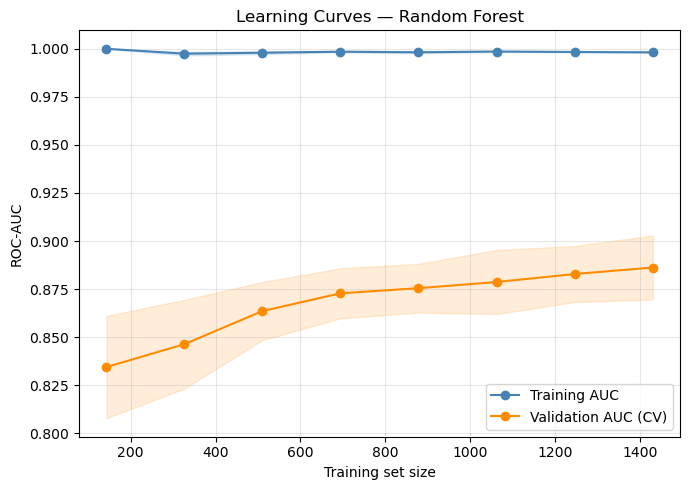

In [15]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='darkorange')
ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Random Forest")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The learning curves reveal a clear overfitting problem. While the validation AUC improves gradually from ~0.835 to ~0.885 as more training data is added, the training AUC remains near-perfect at ~0.999 throughout leaving a persistent gap of ~0.11 that never closes. This indicates the model is memorising training data rather than learning generalisable patterns. Regularisation is required. Constraining max_depth, min_samples_leaf, and min_samples_split should narrow this gap and produce a more reliable model in production.

### 3.7 Feature importance

To understand which variables contribute most to the model’s predictions, we examine the feature importance scores produced by the Random Forest model. These scores measure the **mean decrease in impurity (Gini)**, indicating how much each feature helps reduce classification error across the trees in the forest.

Higher values indicate features that play a larger role in the model’s decision-making process.

Top 15 features by RF importance:
Total_Accepted_Campaigns    0.151669
Recency                     0.149578
Customer_Tenure             0.146018
Total_Spending              0.119843
Income                      0.104538
Total_Purchases             0.060462
Age                         0.058624
NumWebVisitsMonth           0.055621
NumDealsPurchases           0.032659
Teenhome                    0.031604
Marital_Status_Married      0.014504
Education_PhD               0.014329
Marital_Status_Together     0.013394
Marital_Status_Single       0.012330
Kidhome                     0.011728


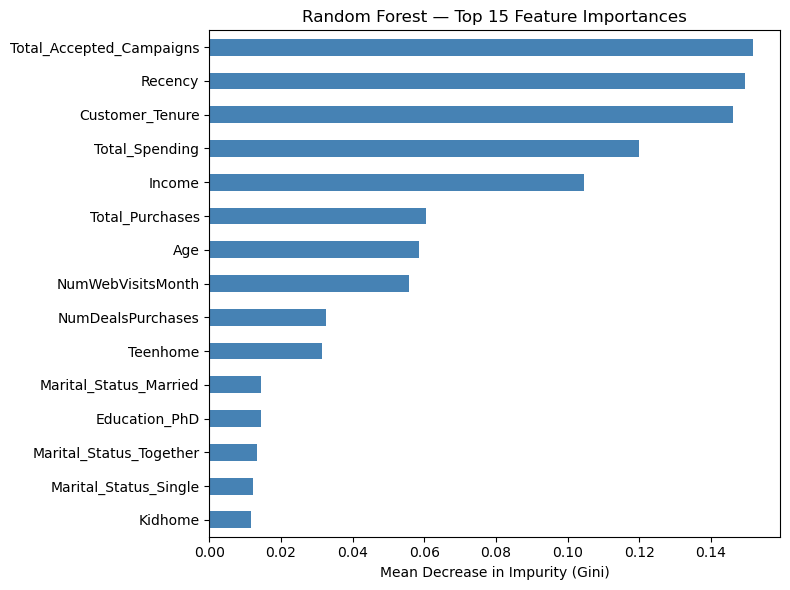

In [16]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 features by RF importance:")
print(importances.head(15).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel("Mean Decrease in Impurity (Gini)")
ax.set_title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

The feature importance results indicate that `Total_Accepted_Campaigns`, `Recency`, and `Customer_Tenure` are the most influential predictors of campaign response. Together, these variables capture patterns of prior engagement and customer activity, suggesting that customers who have previously responded to campaigns and have been active more recently are significantly more likely to respond again.

The strong importance of `Total_Accepted_Campaigns` in particular highlights the persistence of customer behaviour, as past responses are highly indicative of future engagement. At the same time, this may reflect a certain path dependency in the model, where previous outcomes strongly drive predictions.

Spending-related variables such as `Total_Spending`, `Income`, and `Total_Purchases` also contribute meaningfully, indicating that higher-value customers are more likely to engage with marketing efforts. In contrast, demographic characteristics such as `Education` and `Marital_Status` appear much less important, suggesting that behavioural data is considerably more informative than static customer attributes in predicting campaign response.

From a business perspective, these findings imply that targeting strategies should focus on recently active and previously engaged customers, as well as high-spending individuals, in order to maximise campaign effectiveness.

### 3.8 Permutation importance

To obtain a more robust measure of feature importance, we compute **permutation importance** on the test set. This method evaluates the contribution of each feature by randomly shuffling its values and measuring the resulting drop in model performance.

If shuffling a feature leads to a large decrease in ROC-AUC, it indicates that the feature plays an important role in the model’s predictions.

Top 15 features by Permutation Importance (on test set):
                 feature  importance_mean  importance_std
                 Recency         0.076721        0.011857
Total_Accepted_Campaigns         0.075050        0.014662
         Customer_Tenure         0.033484        0.009722
          Total_Spending         0.025260        0.009915
       NumWebVisitsMonth         0.010401        0.005894
                Teenhome         0.008849        0.008639
 Marital_Status_Together         0.004194        0.003010
  Marital_Status_Married         0.003837        0.002158
                  Income         0.002940        0.003783
   Marital_Status_Single         0.002683        0.001575
       NumDealsPurchases         0.001702        0.002316
                 Kidhome         0.001344        0.001374
         Education_Basic         0.000744        0.000203
           Education_PhD         0.000270        0.001767
         Total_Purchases         0.000225        0.004704


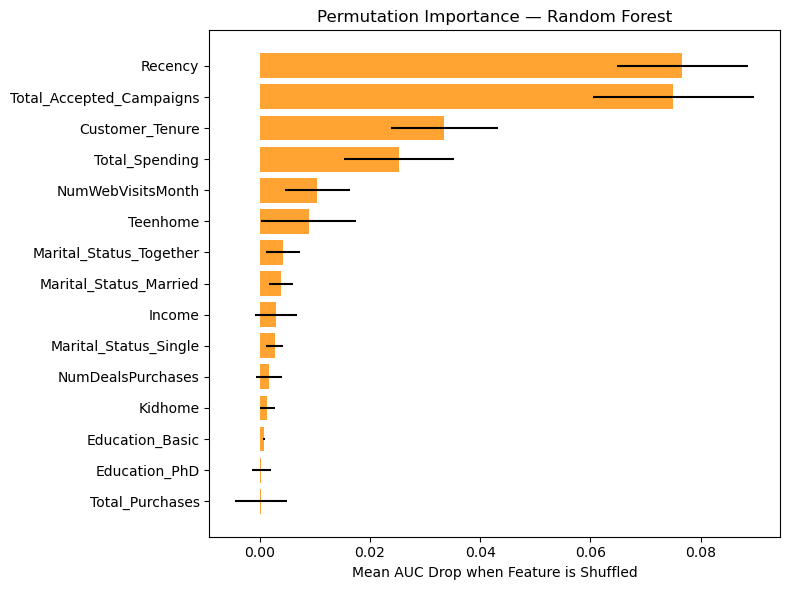

In [17]:
perm_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df = pd.DataFrame({
    'feature':          X_train.columns,
    'importance_mean':  perm_result.importances_mean,
    'importance_std':   perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("Top 15 features by Permutation Importance (on test set):")
print(perm_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top_perm = perm_df.head(15).sort_values('importance_mean')
ax.barh(top_perm['feature'], top_perm['importance_mean'],
        xerr=top_perm['importance_std'], color='darkorange', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Random Forest")
plt.tight_layout()
plt.show()

The permutation importance results confirm that `Recency` and `Total_Accepted_Campaigns` have the largest impact on model performance, as shuffling these variables leads to the greatest drop in AUC. This reinforces the earlier feature importance findings, highlighting that recent customer activity and prior engagement are the strongest predictors of campaign response.

Unlike Gini-based importance, permutation importance reflects the actual contribution of each variable to predictive performance, making these results more robust. The consistency across both methods strengthens the conclusion that behavioural variables play a central role in the model.

Other activity-related features, such as `Customer_Tenure` and `Total_Spending`, also contribute meaningfully, although to a lesser extent. In contrast, demographic variables have minimal impact on model performance, further supporting the idea that customer behaviour is significantly more informative than static characteristics.

### 3.9 SHAP values

To further interpret the model, we compute SHAP (SHapley Additive exPlanations) values. SHAP quantifies how each feature contributes to the model’s prediction by measuring how much it increases or decreases the predicted probability relative to a baseline.

SHAP values provide both **global explanations** (which features are most influential overall) and **local explanations** (how individual features influence a specific prediction).

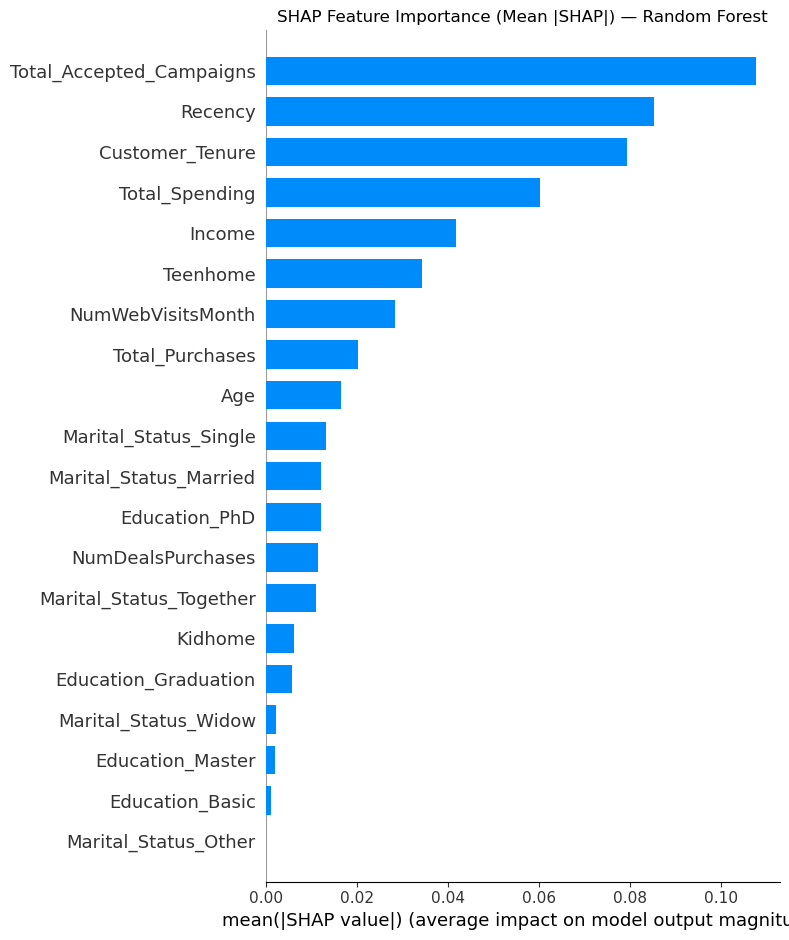

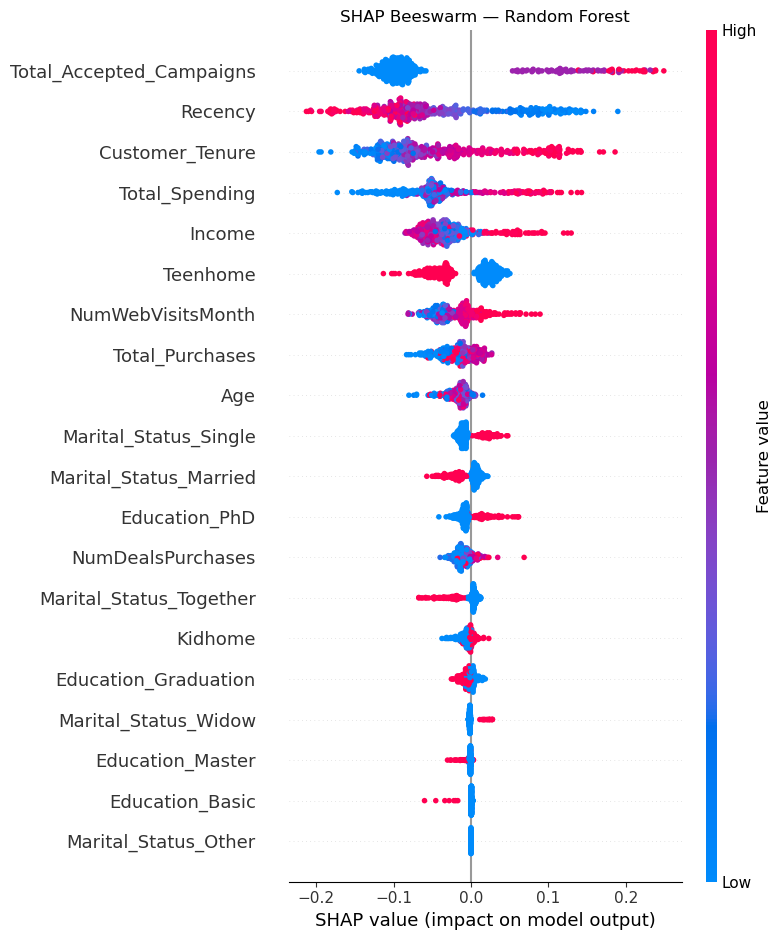

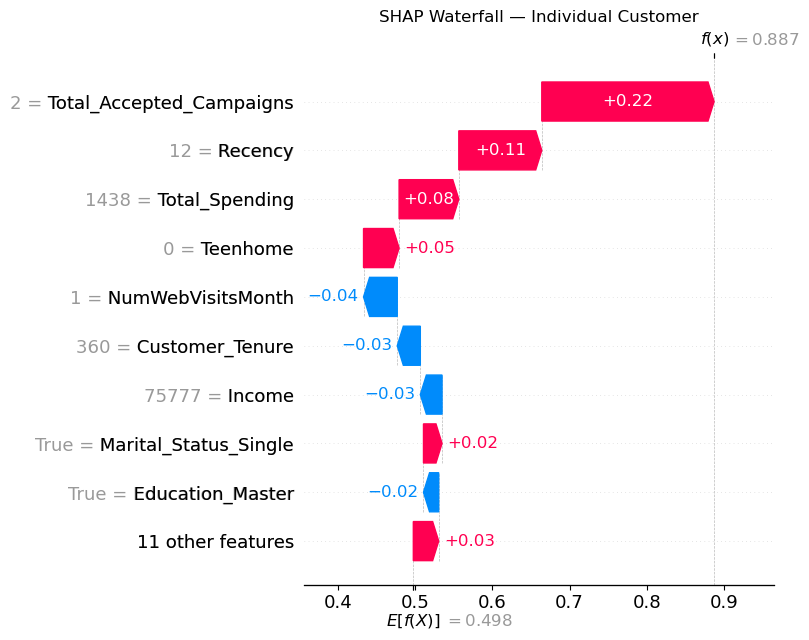

Customer predicted probability: 0.887


In [18]:
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# shap_values is a list [class_0_vals, class_1_vals] for binary RF
# Use index 1 for the positive class (Response = 1)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

# Global summary: bar chart (average absolute SHAP)
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Random Forest")
plt.tight_layout()
plt.show()

# Global beeswarm: shows direction + magnitude of each feature
shap.summary_plot(sv, X_test, show=False)
plt.title("SHAP Beeswarm — Random Forest")
plt.tight_layout()
plt.show()

# Local explanation: explain one individual prediction
top_idx  = np.argmax(y_prob_best)
single_x = X_test.iloc[[top_idx]]

sv_raw = explainer.shap_values(single_x)

# SHAP >= 0.45 returns a 3D array (n_samples, n_features, n_classes)
# SHAP <  0.45 returns a list [class_0_array, class_1_array]
if isinstance(sv_raw, list):
    sv_single    = sv_raw[1][0]           # old API
    base_value   = explainer.expected_value[1]
else:
    sv_single    = sv_raw[0, :, 1]        # new API
    base_value   = explainer.expected_value[1]

shap.waterfall_plot(
    shap.Explanation(
        values        = sv_single,
        base_values   = base_value,
        data          = single_x.values[0],
        feature_names = X_test.columns.tolist()
    ),
    show=False
)
plt.title("SHAP Waterfall — Individual Customer")
plt.tight_layout()
plt.show()
print(f"Customer predicted probability: {y_prob_best[top_idx]:.3f}")

The SHAP analysis reinforces the previous findings by confirming that variables related to **customer engagement and recent activity** are the main drivers of campaign response. In particular, past campaign acceptance, recency, and customer tenure consistently have the strongest influence on the model’s predictions.

Importantly, SHAP values provide insight into the **direction of these effects**, showing that higher levels of engagement and spending tend to increase the predicted probability of response, while lower activity levels reduce it. This highlights the asymmetric impact of customer behaviour on predictions.

Overall, the results confirm that the model relies primarily on **behavioural patterns rather than demographic characteristics**, offering a more interpretable and consistent understanding of the factors driving campaign success.

## 4. Full Model - XGBoost

In this section, we train an XGBoost model, a gradient boosting approach that builds trees sequentially, allowing the model to refine its predictions at each step. Including this model allows us to compare three different approaches, *Logistic Regression*, *Random Forest*, and *Gradient Boosting*, and **assess whether a boosting method can improve predictive performance**.

In [19]:
# scale_pos_weight handles class imbalance in XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale     = neg_count / pos_count
print(f"scale_pos_weight = {scale:.2f}  (neg/pos ratio for class balance)")

param_dist_xgb = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_lambda':        [10, 20, 50],
    'reg_alpha':         [0.05, 1, 2],
    'min_child_weight':  [20, 30, 50],
    'scale_pos_weight':  [neg_count / pos_count],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='auc', random_state=42),
    param_distributions=param_dist_xgb,
    n_iter=100,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_, xgb_search.best_score_)

best_xgb = cast(XGBClassifier, xgb_search.best_estimator_)

y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = best_xgb.predict(X_test)

print(f"XGBoost — ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"XGBoost — Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"XGBoost — F1       : {f1_score(y_test, y_pred_xgb):.4f}")

scale_pos_weight = 5.70  (neg/pos ratio for class balance)
Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'colsample_bytree': np.float64(0.6377771843023713), 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 20, 'n_estimators': 189, 'reg_alpha': 0.05, 'reg_lambda': 20, 'scale_pos_weight': np.float64(5.696629213483146), 'subsample': np.float64(0.8726454675891159)} 0.8898330312584225
XGBoost — ROC-AUC  : 0.8723
XGBoost — Recall   : 0.7015
XGBoost — F1       : 0.5839


The XGBoost model achieves a R**OC-AUC of approximately 0.87**, indicating good ability to distinguish between responding and non-responding customers. However, its overall ranking performance is slightly lower than the Random Forest model observed earlier.

At the same time, the model achieves a **higher recall**, suggesting that it is able to identify a meaningful share of potential responders, which is particularly relevant in marketing contexts where missing potential buyers can be costly. This reflects a trade-off between overall ranking performance and the ability to capture positive cases.

Optimal threshold (F1-maximising): 0.6371
Best OOF F1:                        0.6157


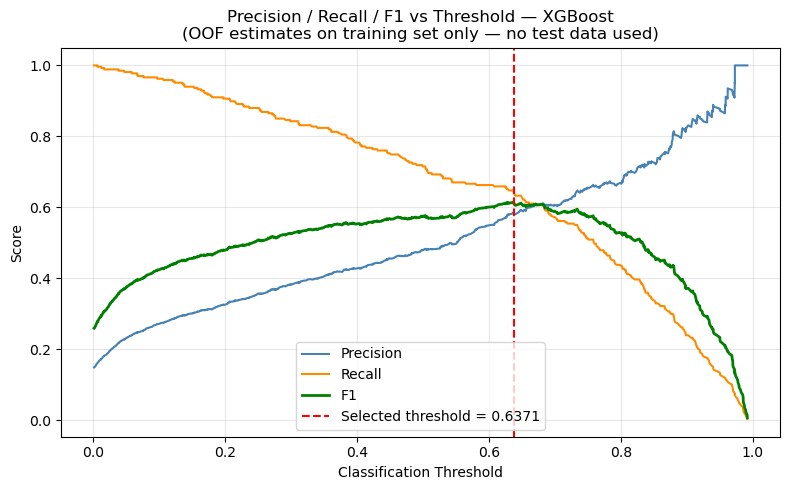


Classification report at OOF-selected threshold = 0.6371:
              precision    recall  f1-score   support

 No Response       0.93      0.91      0.92       381
    Response       0.54      0.63      0.58        67

    accuracy                           0.86       448
   macro avg       0.74      0.77      0.75       448
weighted avg       0.87      0.86      0.87       448



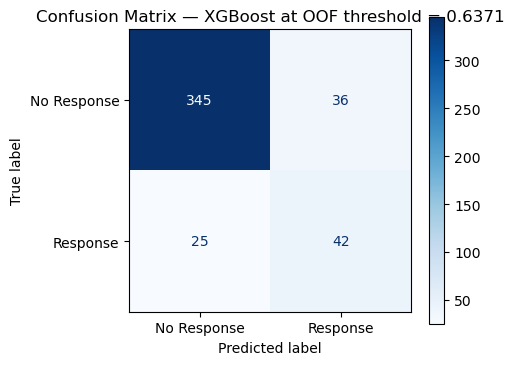

In [20]:
# OOF threshold selection — XGBoost
threshold_xgb, oof_probs_xgb, prec_xgb_curve, rec_xgb_curve, thresh_xgb_curve, f1_xgb_curve = \
    find_best_threshold_oof(best_xgb, X_train, y_train)

# Visualise the full trade-off curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresh_xgb_curve, prec_xgb_curve[:-1], label='Precision', color='steelblue')
ax.plot(thresh_xgb_curve, rec_xgb_curve[:-1],  label='Recall',    color='darkorange')
ax.plot(thresh_xgb_curve, f1_xgb_curve[:-1],   label='F1',        color='green', linewidth=2)
ax.axvline(threshold_xgb, color='red', linestyle='--',
           label=f'Selected threshold = {threshold_xgb:.4f}')
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold — XGBoost\n(OOF estimates on training set only — no test data used)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Apply to test set
y_pred_xgb_tuned = (y_prob_xgb >= threshold_xgb).astype(int)

print(f"\nClassification report at OOF-selected threshold = {threshold_xgb:.4f}:")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['No Response', 'Response']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_tuned,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — XGBoost at OOF threshold = {threshold_xgb:.4f}")
plt.tight_layout()
plt.show()

## 5. Model Comparison

MODEL COMPARISON TABLE
            Threshold  ROC-AUC  Precision  Recall  F1-Score  Accuracy
Model                                                                
LR  — Full     0.5928   0.8784     0.4800  0.7164    0.5749    0.8415
RF  — Full     0.4119   0.8792     0.5750  0.6866    0.6259    0.8772
XGB — Full     0.6371   0.8723     0.5385  0.6269    0.5793    0.8638

Best model by ROC-AUC : RF  — Full
AUC                   : 0.8792


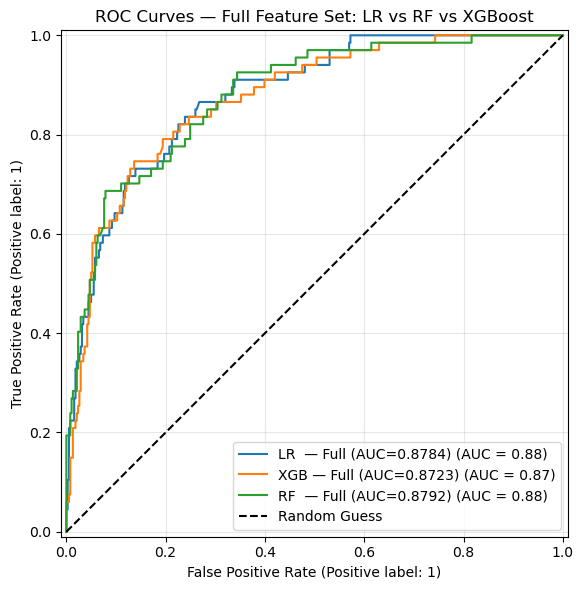

In [23]:
def evaluate_model(model, X_te, y_te, model_name, threshold=0.5):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model':     model_name,
        'Threshold': round(threshold, 4),
        'ROC-AUC':   round(roc_auc_score(y_te, y_prob), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1-Score':  round(f1_score(y_te, y_pred), 4),
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        '_prob':     y_prob
    }

results = []

# Logistic Regression — Full feature set (saved from Model 1)
lr_y_prob_full    = np.load('../data/lr_y_prob_full.npy')
lr_y_pred_full    = np.load('../data/lr_y_pred_full.npy')
lr_threshold_full = np.load('../data/lr_threshold_full.npy')[0]
results.append({
    'Model':     'LR  — Full',
    'Threshold': round(lr_threshold_full, 4),
    'ROC-AUC':   round(roc_auc_score(y_test, lr_y_prob_full), 4),
    'Precision': round(precision_score(y_test, lr_y_pred_full), 4),
    'Recall':    round(recall_score(y_test, lr_y_pred_full), 4),
    'F1-Score':  round(f1_score(y_test, lr_y_pred_full), 4),
    'Accuracy':  round(accuracy_score(y_test, lr_y_pred_full), 4),
    '_prob':     lr_y_prob_full
})

# XGBoost — Full feature set (OOF-tuned threshold)
results.append(evaluate_model(xgb_search.best_estimator_, X_test, y_test, 'XGB — Full', threshold=threshold_xgb))

# Random Forest — Full feature set (OOF-tuned threshold)
results.append(evaluate_model(best_rf, X_test, y_test, 'RF  — Full', threshold=threshold_rf))

# Build and display comparison table
comparison_df = (
    pd.DataFrame(results)
    .drop(columns='_prob')
    .set_index('Model')
    .sort_index()
)
print('MODEL COMPARISON TABLE')
print(comparison_df.to_string())

best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f'\nBest model by ROC-AUC : {best_model_name}')
print(f'AUC                   : {comparison_df.loc[best_model_name, "ROC-AUC"]}')

# ROC curves: all three full-dataset models
fig, ax = plt.subplots(figsize=(8, 6))
for entry in results:
    RocCurveDisplay.from_predictions(
        y_test, entry['_prob'],
        ax=ax, name=f"{entry['Model']} (AUC={entry['ROC-AUC']})"
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title('ROC Curves — Full Feature Set: LR vs RF vs XGBoost')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The comparison across models shows that performance is very similar in terms of **ROC-AUC**, with **Random Forest** achieving the highest value (**0.8792**), closely followed by **Logistic Regression** (**0.8784**), while **XGBoost** performs slightly lower (**0.8723**). This indicates that all three models have strong and comparable discriminative ability, with only marginal differences.

Looking beyond ROC-AUC, clearer trade-offs emerge across the remaining metrics. **Logistic Regression** achieves the highest **recall** (**0.7164**), meaning it is most effective at identifying potential responders, though this comes with lower **precision** (**0.4800**). In contrast, **Random Forest** delivers the highest **precision** (**0.5750**) and also achieves the best **F1-score** (**0.6259**), indicating the most balanced performance between identifying responders and avoiding false positives. **XGBoost** performs slightly worse across these metrics, with lower recall and F1-score, suggesting a less optimal balance overall.

## 8. Summary of Results

The goal of this project is to predict which customers are most likely to accept a monthly food basket subscription campaign. This is a binary classification problem with a class imbalance (~15% positive responses), meaning a naive model could achieve high accuracy simply by predicting "no" for everyone which would be no good business recommendation from a marketing perspective.

To identify which is the best model to predict which customers are most likely to accept a new marketing campaign we look at three main metrics, **AUC, recall and precision**:

In a targeted marketing context, the company does not simply want a yes/no prediction, but rather to rank customers by their probability of responding, so that the marketing budget can be directed at the most receptive segment (e.g. the top 20–30% most likely to accept). The **ROC-AUC** measures the model's ability to correctly rank a positive customer above a negative one, across all possible classification thresholds. Based on this metric, **Random Forest achieves the highest AUC (0.8792)**, with Logistic Regression performing almost identically (0.8784) and XGBoost slightly lower (0.8723). This indicates that all three models have very similar and strong ranking ability, and that differences in performance are marginal.

**Recall** measures the proportion of actual buyers that the model successfully identifies, i.e. how many true responders we capture. In the marketing context, a missed potential customer is a missed revenue opportunity. If the model fails to flag a customer who would have accepted, the company never contacts them and loses that sale entirely. The **Logistic Regression model achieves the highest recall (0.7164)** among all three models, meaning it correctly identifies approximately 72% of all genuine campaign acceptors. By comparison, both Random Forest and XGBoost capture a smaller share of true positives. From a business perspective, this makes Logistic Regression more aligned with the objective of maximising customer acquisition.

This aligns with our project plan's explicit design choice: "*In marketing it's better to contact more potential buyers than miss them*", and justifies using class_weight='balanced' and threshold tuning to favour recall.

**Precision** measures how many of the customers flagged by the model as likely buyers actually convert. A lower precision means the company is spending resources contacting customers who will not respond. **Random Forest achieves the highest precision (0.5750)**, while Logistic Regression is lower, meaning it produces more false positives. However, given the relatively low marginal cost of outreach (e.g. email or digital advertising), the cost of contacting some non-responders is significantly lower than the cost of missing true responders. The trade-off therefore favours the higher-recall Logistic Regression model.

That said, precision should not be ignored. It informs budget efficiency: if the company has a fixed campaign budget, they may want to target a higher-precision, top-decile subset of the probability rankings produced by the LR model, combining the ranking power of AUC with a precision-aware threshold.

Random Forest achieves the highest accuracy, but this is largely a reflection of the class imbalance in the dataset. With ~85% of customers not responding, a model that predicts “no” for everyone would already achieve high accuracy. Therefore, accuracy is not an informative metric in this context, as it does not capture the model’s ability to identify true responders.

Conclusion The **Logistic Regression (Full)** model is the most appropriate choice for this business case. It combines near-best ROC-AUC (strong ranking ability) with the highest recall, ensuring that the majority of potential responders are identified. Additionally, Logistic Regression remains a simpler and more interpretable model, which is valuable for communicating results to stakeholders and operationalising the model outputs.

If business priorities were to shift towards cost reduction and more targeted outreach, then a higher-precision model such as Random Forest would become preferable, as it focuses on customers most likely to convert.